<a href="https://colab.research.google.com/github/avikumart/DA-DS-Questions/blob/main/ML_coding/Ml_coding_and_interviewn_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Eigen Vector and Eigen values

In [1]:
import numpy as np

A = np.array([[1,2,3],[3,2,1],[1,1,1]])

# do eigen vector and eigen values of the Matrix A
eigenval , eigenvec = np.linalg.eig(A)

print(eigenval)
print(eigenvec)

[ 5.00000000e+00 -1.00000000e+00  8.95297709e-17]
[[ 6.09233653e-01  7.07106781e-01  4.08248290e-01]
 [ 7.20003408e-01 -7.07106781e-01 -8.16496581e-01]
 [ 3.32309265e-01 -6.91757621e-17  4.08248290e-01]]


In [2]:
v = eigenvec[:,0]
lambda_ = eigenval[0]

left = A @ v
right = lambda_ * v

print("Av:\n", left)
print("\nlamba:\n", right)

Av:
 [3.04616827 3.60001704 1.66154633]

lamba:
 [3.04616827 3.60001704 1.66154633]


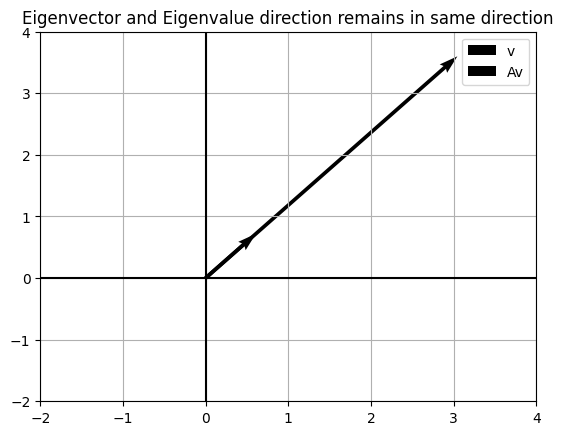

In [3]:
import matplotlib.pyplot as plt

v = eigenvec[:,0]
Av = A @ v

plt.axhline(0, color="black")
plt.axvline(0 , color="black")


# plot the qiuver plot
plt.quiver(0,0,v[0],v[1], angles="xy", scale_units="xy", scale=1, label="v")
plt.quiver(0,0,Av[0],Av[1], angles="xy", scale_units="xy", scale=1, label="Av")

plt.legend()
plt.xlim(-2,4)
plt.ylim(-2,4)
plt.grid()
plt.title("Eigenvector and Eigenvalue direction remains in same direction")
plt.show()


In [4]:
# applying to the PCA
from sklearn.datasets import load_iris
import numpy as np

X = load_iris().data

X_std = (X - X.mean(axis=0)) / X.std(axis=0)

cov = np.cov(X_std, rowvar=False)

eig_vals, eig_vecs = np.linalg.eig(cov)

print("Eigenvalues:\n", eig_vals)
print("\nEiganvectors (principal components):\n", eig_vecs)

Eigenvalues:
 [2.93808505 0.9201649  0.14774182 0.02085386]

Eiganvectors (principal components):
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [5]:
explained_variance = eig_vals / eig_vals.sum()
explained_variance

array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

## Gradient Descent

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

X = np.linspace(0, 10, 50)
y = 3*X + 5 + np.random.randn(50)*2

In [7]:
# step 2 - initialize the params
m = 0
c = 0
lr = 0.01

# step 3 - Implement Gradient Descent loop
losses = []

for epoch in range(500):
  y_pred = m*X + c

  dm = (-2/len(X)) * np.sum(X * (y - y_pred))
  dc = (-2/len(X)) * np.sum(y - y_pred)

  # update weights
  m = m -lr*dm
  c = c - lr*dc

  # compute loss
  loss = np.mean((y - y_pred)**2)
  losses.append(loss)

print("Learned slope m:", m)
print("Learned intercept c:", c)

Learned slope m: 2.791232212001275
Learned intercept c: 6.201066048318193


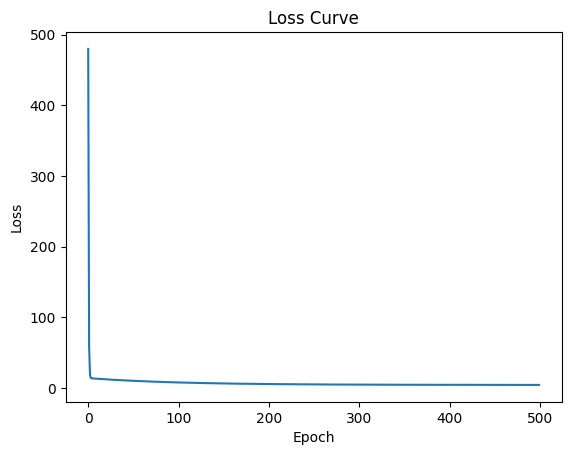

In [8]:
# plot the loss curve
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.show()

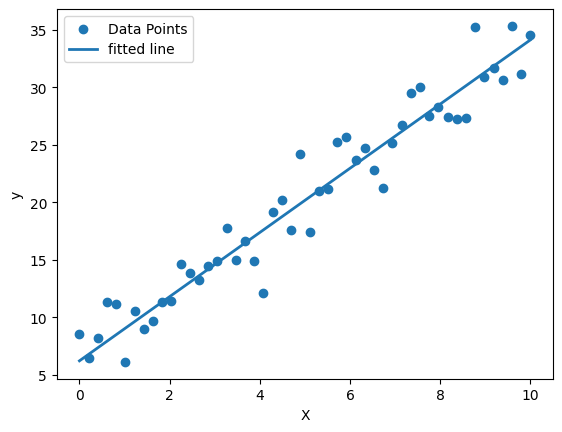

In [9]:
# visualize the fitted line
plt.scatter(X, y, label="Data Points")
plt.plot(X, m*X + c, label="fitted line", linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## SGD compute

In [10]:
# compute the SGD
m, c = 0, 0
lr = 0.01
SGD_losses = []

for epoch in range(1000):
  i = np.random.randint(0, len(X))
  Xi = X[i]
  yi = y[i]

  y_pred = m*Xi + c

  # gradients
  dm = -2 * Xi * (yi - y_pred)
  dc = -2 * (yi - y_pred)

  m = m - lr*dm
  c = c - lr*dc

  # full dataset loss
  y_pred_loss = m*X + c
  loss = np.mean((y - y_pred_loss)**2)
  SGD_losses.append(loss)

print("Learned slope m:", m)
print("Learned intercept c:", c)

Learned slope m: 2.838811886814019
Learned intercept c: 6.506691783912228


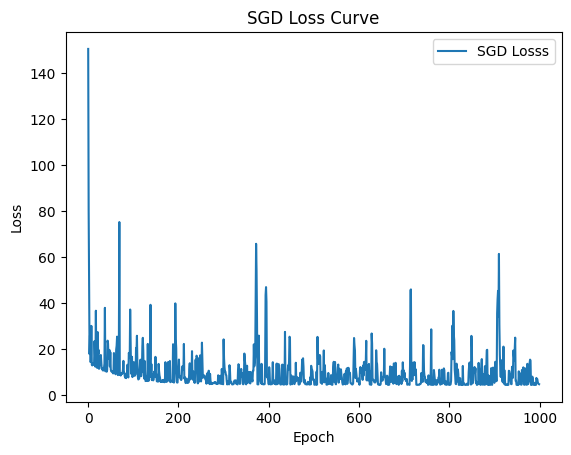

In [11]:
# plot the SGD losses
plt.plot(SGD_losses, label="SGD Losss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGD Loss Curve")
plt.legend()
plt.show()

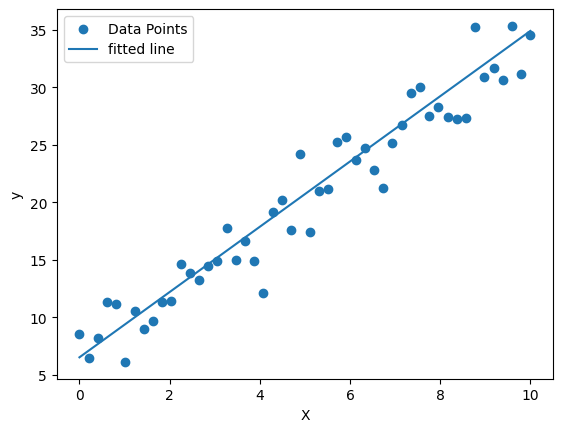

In [12]:
plt.scatter(X, y, label="Data Points")
plt.plot(X, m*X + c, label="fitted line")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Mini batch gradient descent

In [13]:
m ,c = 0, 0
lr = 0.01
batch_size = 10
minibatch_losses = []

for eppoch in range(500):
  i = np.random.choice(len(X), size=batch_size, replace=False)
  Xi = X[i]
  yi = y[i]

  y_pred = m*Xi + c

  dm = (-2/batch_size) * np.sum(Xi * (yi - y_pred))
  dc = (-2/batch_size) * np.sum(yi - y_pred)

  m = m - lr*dm
  c = c - lr*dc

  y_pred_loss = m*X + c
  loss = np.mean((y - y_pred_loss)**2)
  minibatch_losses.append(loss)

print("Learned slope m:", m)
print("Learned intercept c:", c)

Learned slope m: 2.872375580383169
Learned intercept c: 6.089975263863068


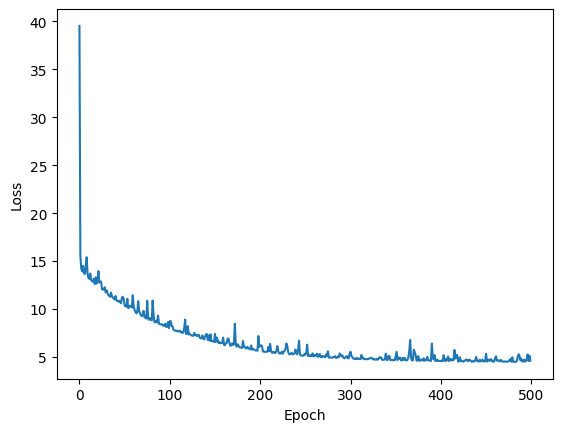

In [14]:
# plot the mini_batch loss
plt.plot(minibatch_losses, label="Mini-batch Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

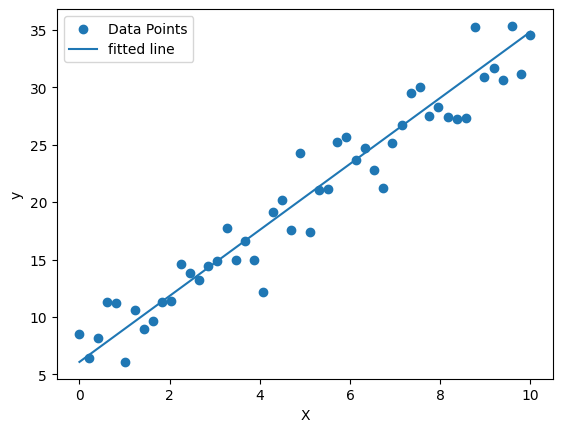

In [15]:
# plot the scatter plot of the predictions
plt.scatter(X, y, label="Data Points")
plt.plot(X, m*X + c, label="fitted line")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Underfitting, overfitting and balanced


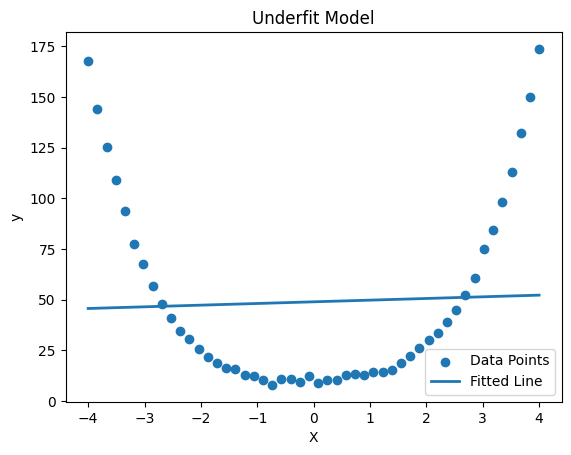

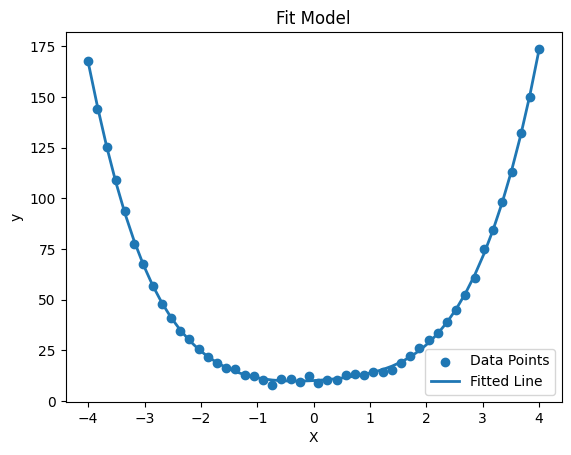

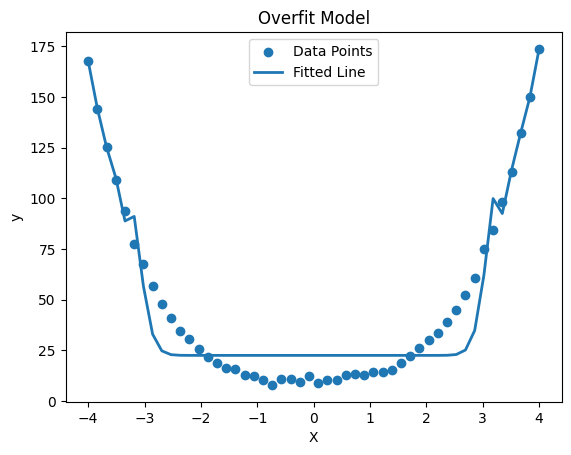

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# create dataset
np.random.seed(0)
X = np.linspace(-4, 4, 50)
y = 0.5 * X**4 - 2 + 2*X**2 + X + 12 + np.random.randn(50)
X = X.reshape(-1, 1)

# create polynomial features
def polyfeatures(degree, title):
  poly = PolynomialFeatures(degree=degree)
  X_poly = poly.fit_transform(X)

  # fit the linear regression model
  model = LinearRegression()
  model.fit(X_poly, y)

  # predict the values
  X_grid = np.linspace(-4, 4, 50).reshape(-1, 1)
  X_grid_poly = poly.transform(X_grid)
  y_pred = model.predict(X_grid_poly)

  # plot the data
  plt.scatter(X, y, label="Data Points")
  plt.plot(X_grid, y_pred, label="Fitted Line", linewidth=2)
  plt.xlabel("X")
  plt.ylabel("y")
  plt.title(title)
  plt.legend()
  plt.show()

# underfit model
polyfeatures(1, "Underfit Model")

# fit model
polyfeatures(10, "Fit Model")

# overfit
polyfeatures(50, "Overfit Model")

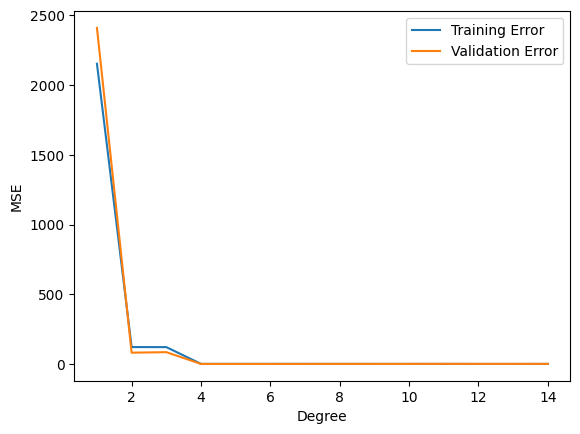

In [17]:
# train and validation loss curves (under/overfit)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

train_errors = []
val_errors = []

degrees = range(1,15)

for d in degrees:
  poly = PolynomialFeatures(d)
  X_train_poly = poly.fit_transform(x_train)
  X_val_poly = poly.transform(x_val)

  model = LinearRegression()
  model.fit(X_train_poly, y_train)

  train_pred = model.predict(X_train_poly)
  val_pred = model.predict(X_val_poly)

  train_errors.append(mean_squared_error(y_train, train_pred))
  val_errors.append(mean_squared_error(y_val, val_pred))

# plot the errors
plt.plot(degrees, train_errors, label="Training Error")
plt.plot(degrees, val_errors, label="Validation Error")
plt.xlabel("Degree")
plt.ylabel("MSE")
plt.legend()
plt.show()

## Regularization (Ridge, Lasso, ElasticNet)

In [18]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

poly = PolynomialFeatures(degree=10)
X_poly = poly.fit_transform(X)

# Ridge
ridge = Ridge(alpha=0.1)
ridge.fit(X_poly, y)

# lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_poly, y)

# elastic
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_poly, y)


# print the model weights
print("ridge coeffs", ridge.coef_)
print("lasso coeffs", lasso.coef_)
print("elastic coeffs", elastic.coef_)

ridge coeffs [ 0.00000000e+00  1.48663888e+00  1.95415698e+00 -4.20776710e-01
  5.40834798e-01  8.69632077e-02 -1.04362193e-02 -6.99906562e-03
  9.51366153e-04  1.89770548e-04 -2.77364387e-05]
lasso coeffs [ 0.00000000e+00  6.90431006e-01  2.03817198e+00  4.43924753e-02
  4.67309702e-01 -2.01620896e-03  3.48683468e-03 -1.99970809e-04
 -2.26967840e-05  1.04451120e-05 -4.67545824e-06]
elastic coeffs [ 0.00000000e+00  6.91288113e-01  1.88483862e+00  5.29546193e-02
  5.00892113e-01 -3.69563236e-03  1.31288914e-03 -1.06770074e-04
 -1.94427531e-05  9.13595672e-06 -2.34840361e-06]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.314e+01, tolerance: 1.087e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.057e+01, tolerance: 1.087e+01
  model = cd_fast.enet_coordinate_descent(


## XAI - SHAP

/tmp/ipykernel_298/1391355893.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X)


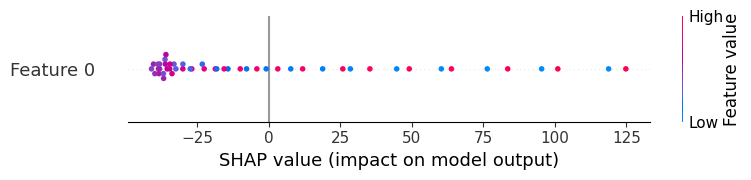

In [19]:
import shap
import xgboost  as xgb

# fit the model
model = xgb.XGBRegressor().fit(X,y)

# shap explain
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

## SHAP bar plot

/tmp/ipykernel_298/1532457554.py:41: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="dot", show=True)


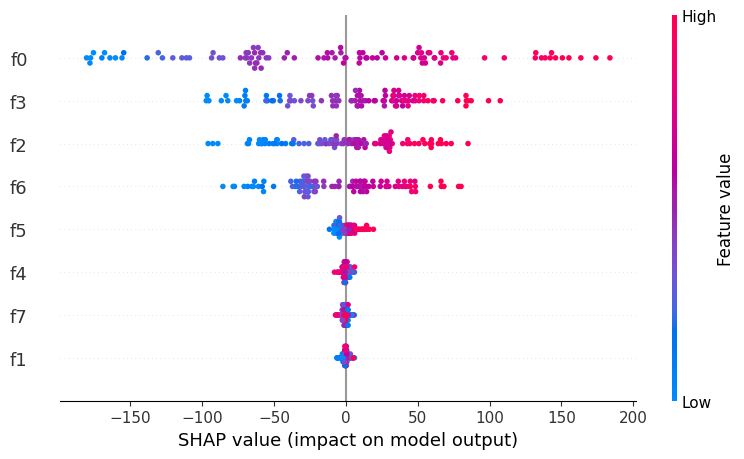

/tmp/ipykernel_298/1532457554.py:44: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)


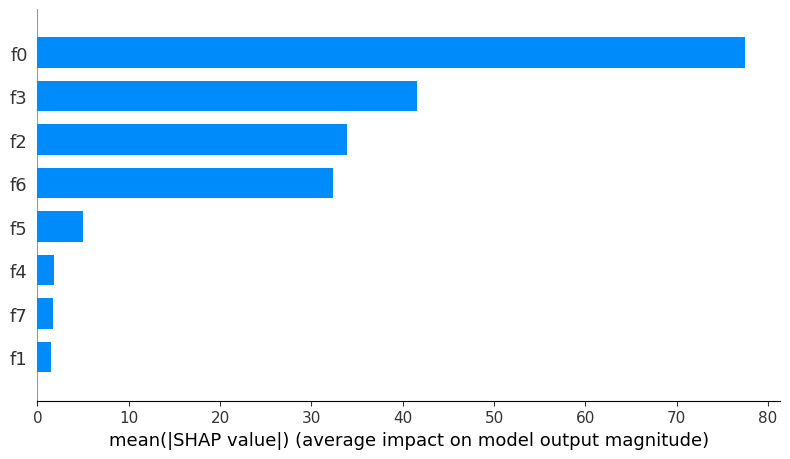

<Figure size 1000x600 with 0 Axes>

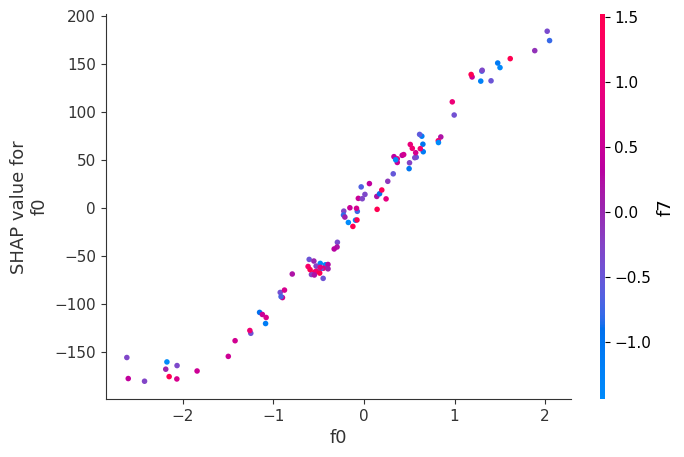

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

try:
  from xgboost import XGBRegressor
  MODEL = "xgb"
except ImportError:
  XGBRegressor = None
  MODEL = "rf"

import shap

X, y = make_regression(n_samples=500, n_features=8, n_informative=5, noise=5, random_state=42)

feature_names = [f"f{i}" for i in range(X.shape[1])]

X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name="target")

# train and test split  of the dataset
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# fit a model
if MODEL == "xgb":
  model = xgb.XGBRegressor(n_estimators=100, max_depth=4, random_state=42).fit(X_train, y_train)
else:
  model = RandomForestRegressor().fit(X_train, y_train)


# explainer using the shape
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=True)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_idx = np.argmax(mean_abs_shap)
top_features = X_test.columns[top_idx]

plt.figure(figsize=(10, 6))
shap.dependence_plot(top_features, shap_values, X_test, show=True)

## Model Training

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, KFold, LeaveOneOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# load dataset
data = load_iris()
X, y = data.data, data.target

# model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 5 fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kf, scoring="accuracy")
print("Cross-validation scores:", cv_scores)
print("Mean accuracy:", np.mean(cv_scores))

# LOOCV # computationally very expensive
lo = LeaveOneOut()
loo_scores = cross_val_score(model, X, y, cv=lo, scoring="accuracy")
print("LOOCV scores:", loo_scores)
print("Mean accuracy:", np.mean(loo_scores))

Cross-validation scores: [1.         0.96666667 0.93333333 0.93333333 0.96666667]
Mean accuracy: 0.9600000000000002
LOOCV scores: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1.
 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]
Mean accuracy: 0.9533333333333334


## Time series cross validation

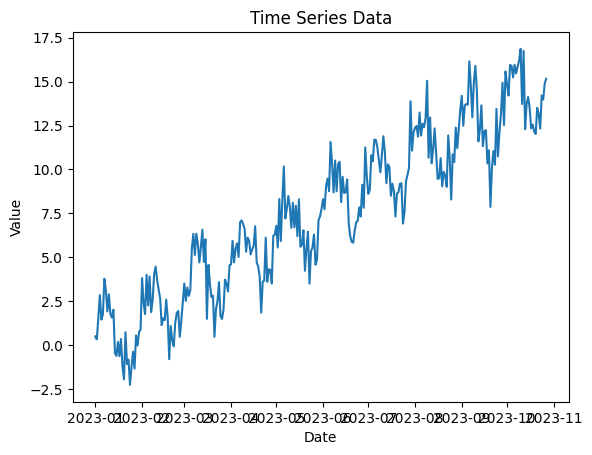

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error


np.random.seed(42)
n = 300
dates = pd.date_range("2023-01-01", periods=n, freq="D")
t = np.arange(n)
y = 0.05 *t + 2*np.sin(2*np.pi*t/30) + np.random.randn(n)

plt.plot(dates, y)
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Time Series Data")
plt.show()

In [23]:
df = pd.DataFrame({"Date": dates, "Value": y})
df.set_index("Date", inplace=True)
df["lag1"] = df["Value"].shift(1).fillna(method="bfill")
df["lag2"] = df["Value"].shift(2).fillna(method="bfill")
df["lag3"] = df["Value"].shift(3).fillna(method="bfill")

features = ["lag1", "lag2", "lag3"]
target = "Value"

/tmp/ipykernel_298/3754636948.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["lag1"] = df["Value"].shift(1).fillna(method="bfill")
/tmp/ipykernel_298/3754636948.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["lag2"] = df["Value"].shift(2).fillna(method="bfill")
/tmp/ipykernel_298/3754636948.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["lag3"] = df["Value"].shift(3).fillna(method="bfill")


In [24]:
from numba import test
# expanding and sliding window logic
def rolling_eval(df, train_size, horizon=1, step=30, expanding=True):
  rmse = []
  indices = []
  start = 0
  while True:
    train_end = start + train_size
    test_start = train_end
    test_end = test_start + horizon
    if test_end > len(df):
      break
    train_idx = range(0,train_end)
    test_idx = range(test_start, test_end)
    X_train, y_train = df[features].iloc[train_idx], df[target].iloc[train_idx]
    X_test, y_test = df[features].iloc[test_idx], df[target].iloc[test_idx]

    # ridge modeling
    model = Ridge(alpha=0.1)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse.append(mean_squared_error(y_test, pred))
    indices.append(test_idx)

    if expanding:
      start += step
      train_size += step
    else:
      start += 1

  return indices, rmse

In [25]:
# run the function for expanding functino
dates, rmes = rolling_eval(df, train_size=100, horizon=1, step=30, expanding=True)


# sliding window
dates_slides, rmes_slides = rolling_eval(df, train_size=100, horizon=1, step=3, expanding=False)

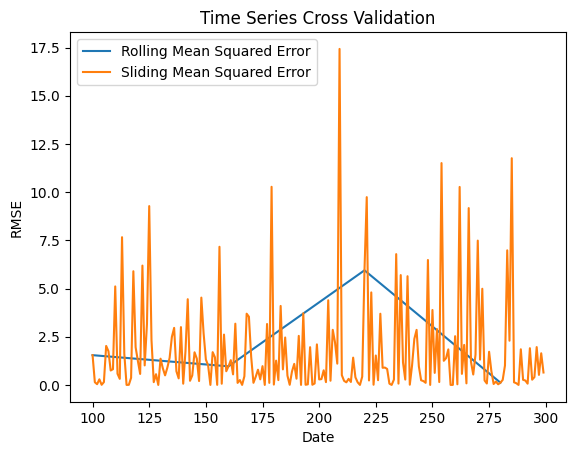

In [26]:
# plot the Time series CV
plt.plot(dates, rmes, label="Rolling Mean Squared Error")
plt.plot(dates_slides, rmes_slides, label="Sliding Mean Squared Error")
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("Time Series Cross Validation")
plt.legend()
plt.show()

## Train val and test dataset workflow

In [27]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# load the dataset
data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target

# split the dataset
X_temp, X_test, y_temp, y_test = train_test_split(X,y, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)


print("train data size:", X_train.shape)
print("validation data size:", X_val.shape)
print("test data size:", X_test.shape)
print("X temp:", X_temp.shape)

# train the random forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# evals
train_pred = model.predict(X_train)
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

# metrics
train_rmse = mean_squared_error(y_train, train_pred)
val_rmse = mean_squared_error(y_val, val_pred)
test_rmse = mean_squared_error(y_test, test_pred)

# print the metrics
print("Train RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)
print("Test RMSE:", test_rmse)

train data size: (14448, 8)
validation data size: (2064, 8)
test data size: (4128, 8)
X temp: (16512, 8)
Train RMSE: 0.03545954430062101
Validation RMSE: 0.27066909784659515
Test RMSE: 0.25847140640214633


In [28]:
# now import the various ML models to train model as a ensemble of multiple models
import numpy as np
from sklearn.utils import resample
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

# train test split the california housing dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# boostraping  manually: train many trees on many boostrap samples
n_boot = 100
trees = []
preds = []
for i in range(n_boot):
  X_boot, y_boot = resample(X_train, y_train, random_state=i)
  tree = DecisionTreeRegressor(max_depth=6, random_state=42)
  tree.fit(X_boot, y_boot)
  trees.append(tree)
  preds.append(tree.predict(X_test))

# average the predictions
avg_preds = np.mean(np.array(preds), axis=0)
mse = mean_squared_error(y_test, avg_preds)
print("MSE:", mse)


MSE: 0.41676827346097295


## hyper parameter tuning

In [29]:
# hyperparam_tuning.ipynb cell
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint
from sklearn.svm import SVR
import time

X_small = X_train.sample(2000, random_state=42)  # sample to speed up search
y_small = y_train.loc[X_small.index]

svr = SVR()

# Grid search (try a grid)
param_grid = {"C": [0.1, 1, 10],
              "gamma": ["scale", 0.01, 0.001],
              "kernel": ["rbf"]}
grid = GridSearchCV(svr, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
t0 = time.time()
grid.fit(X_small, y_small)
print("Grid best params:", grid.best_params_, "time(s):", round(time.time()-t0,1))
print("Grid best CV RMSE:", (-grid.best_score_)**0.5)

# Randomized search (search wider space)
param_dist = {"C": [0.01, 0.1, 1, 10, 100],
              "gamma": [0.1, 0.01, 0.001, 'scale'],
              "kernel": ['rbf']}
rand = RandomizedSearchCV(svr, param_dist, n_iter=8, cv=3, scoring='neg_mean_squared_error', random_state=0, n_jobs=-1)
t1 = time.time()
rand.fit(X_small, y_small)
print("Random best params:", rand.best_params_, "time(s):", round(time.time()-t1,1))
print("Random best CV RMSE:", (-rand.best_score_)**0.5)

Grid best params: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'} time(s): 8.1
Grid best CV RMSE: 1.0285965025602994
Random best params: {'kernel': 'rbf', 'gamma': 0.001, 'C': 100} time(s): 11.5
Random best CV RMSE: 1.0781723654074058


# training time measurement and scaling

In [30]:
import time
from sklearn.ensemble import RandomForestRegressor

sizes = [100,1000, 2000, 5000]
times = [0]
for s in sizes:
  if s > X.shape[0]:
    break
  Xt = X.sample(s, random_state=0)
  yt = y.loc[Xt.index]
  model = RandomForestRegressor(n_estimators=100, random_state=0)
  t0 = time.time()
  model.fit(Xt, yt)
  times.append(time.time()-t0)
  print("Training size:", s, "time(s):", times[-1])

Training size: 100 time(s): 0.17564797401428223
Training size: 1000 time(s): 0.987360954284668
Training size: 2000 time(s): 2.3846065998077393
Training size: 5000 time(s): 6.639003038406372


## Learning Curves

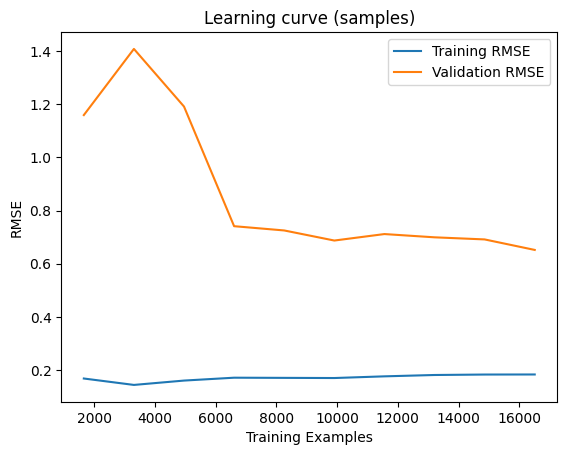

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestRegressor

# learning curves vs samples
est = RandomForestRegressor(n_estimators=100, random_state=0)
train_sizes, train_scores, val_scores = learning_curve(est, X, y,
                                                        train_sizes=np.linspace(0.1, 1, 10),
                                                        cv=5,
                                                        scoring="neg_mean_squared_error")

train_rmse = np.sqrt(-train_scores.mean(axis=1))
val_rmse = np.sqrt(-val_scores.mean(axis=1))

plt.plot(train_sizes, train_rmse, label="Training RMSE")
plt.plot(train_sizes, val_rmse, label="Validation RMSE")
plt.xlabel("Training Examples")
plt.ylabel("RMSE")
plt.legend()
plt.title("Learning curve (samples)")
plt.show()


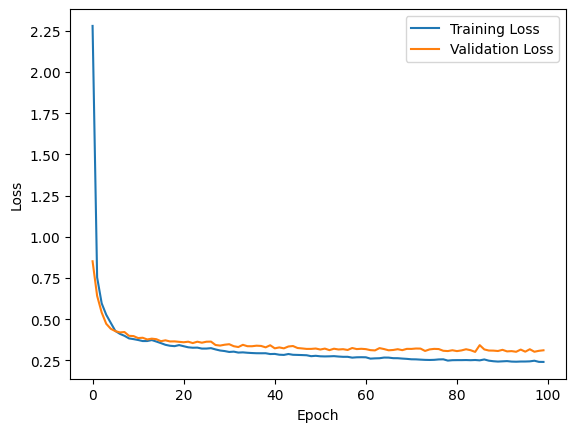

In [32]:
# epoch based learning curve using keras
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# prepare small regression dataset
X_nn = X.sample(5000, random_state=0)
y_nn = y.loc[X_nn.index]

# train and test split
X_train, X_test, y_train, y_test = train_test_split(X_nn, y_nn, test_size=0.2, random_state=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = models.Sequential([
  layers.Input(shape=(X_train.shape[1],)),
  layers.Dense(64, activation="relu"),
  layers.Dense(32, activation="relu"),
  layers.Dense(1)
])
model.compile(optimizer="adam", loss="mse", metrics=[tf.keras.metrics.RootMeanSquaredError()])

history = model.fit(X_train_scaled, y_train, validation_data=(X_test_scaled, y_test), epochs=100, batch_size=32, verbose=0)

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Linear regression + MSE + RMSE + MAE

Mean Squared Error: 5.328270609194224
Mean Absolute Error: 1.8548710384336702
R-squared: 0.9585586457601137


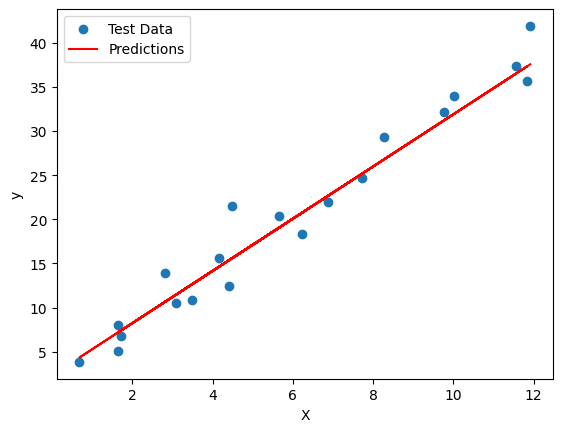

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Generate the simple linear data with noise
np.random.seed(30)
X = np.random.rand(100, 1) * 12
y = 3*X.squeeze() + 2 + np.random.randn(100)*2

# train and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model load
model = LinearRegression()
model.fit(X_train, y_train)

# model prediction
y_pred = model.predict(X_test)

# model evaluation
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# print the results
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)

# ploting
plt.scatter(X_test, y_test, label="Test Data")
plt.plot(X_test, y_pred, color="red", label="Predictions")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Fit the linear regression on the toy dataset

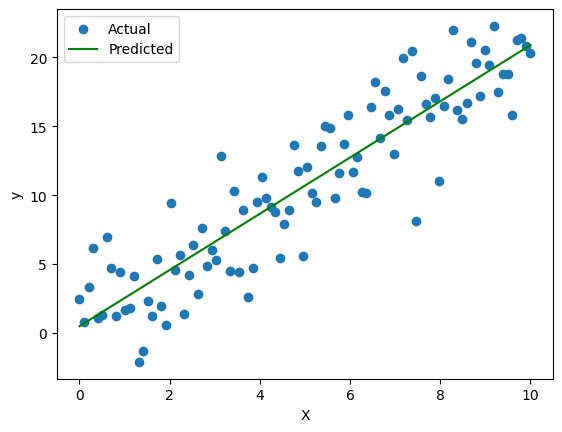

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# create the dataset for the linear rgression
X = np.linspace(0, 10, 100)
y = 2*X + 1 + np.random.normal(0,3,100)

df = pd.DataFrame({"X": X, "y": y})
df.head()

# fit the model to the linear regression
model = LinearRegression()
model.fit(df[["X"]], df["y"])

df["pred"] = model.predict(df[["X"]])
df["residuals"] = df["y"] - df["pred"]

# plot the results
plt.scatter(df["X"], df["y"], label="Actual")
plt.plot(df["X"], df["pred"], label="Predicted", color="green")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

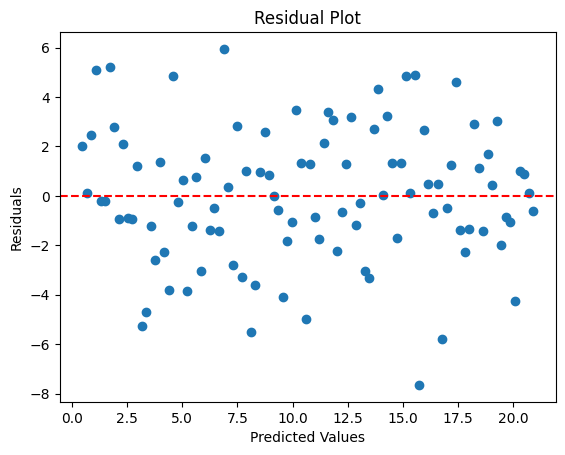

In [35]:
# residual plot
plt.scatter(df["pred"], df["residuals"])
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

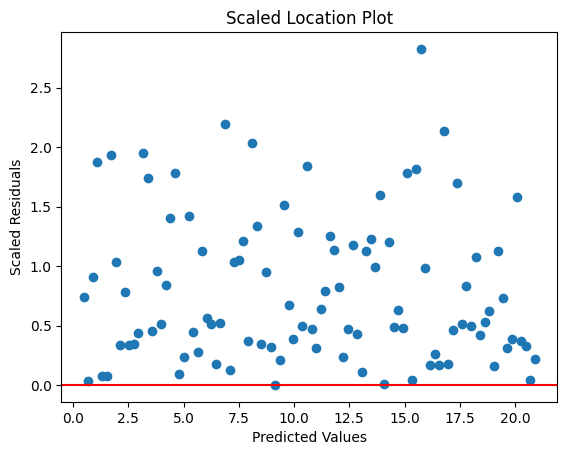

In [36]:
# 3. scaled location plot
import numpy as np

scaled_residuals = (np.abs(df["residuals"]) / np.sqrt(np.mean(df["residuals"]**2)))

# plot the scatter chart
plt.scatter(df["pred"], scaled_residuals)
plt.title("Scaled Location Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Scaled Residuals")
plt.axhline(0, color="red")
plt.show()

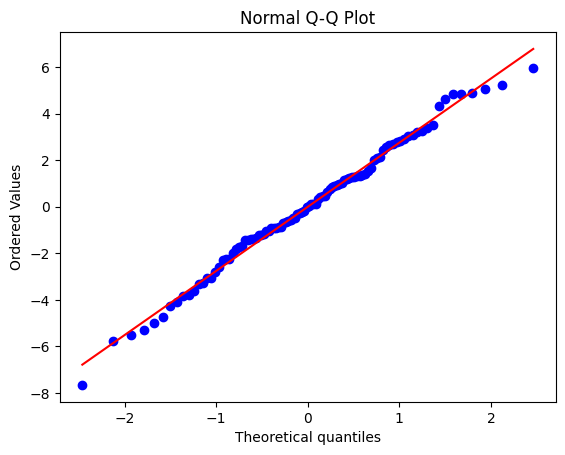

In [37]:
# normal q-q plot

import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df["residuals"], dist="norm", plot=plt)
plt.title("Normal Q-Q Plot")
plt.show()

In [38]:
# 5. durbin-watson test for autocorrelation
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(df["residuals"])
print("Durbin Watson:", dw)

Durbin Watson: 2.042461705306249


- 2 = no autocorrelation
- <1 or >3 = serious autocorrelation

In [39]:
# outliear detection using cook's distance
import statsmodels.api as sm

X2 = sm.add_constant(df["X"])
model = sm.OLS(df["y"], X2).fit()
df["cook_distance"] = model.get_influence().summary_frame()["cooks_d"]

# print the results
print(df.sort_values("cook_distance", ascending=False).head())

           X          y       pred  residuals  cook_distance
74  7.474747   8.090260  15.740360  -7.650100       0.069643
3   0.303030   6.175150   1.100161   5.074989       0.066560
6   0.606061   6.949760   1.718761   5.230998       0.063911
13  1.313131  -2.113578   3.162161  -5.275739       0.050941
79  7.979798  10.996889  16.771360  -5.774471       0.047466


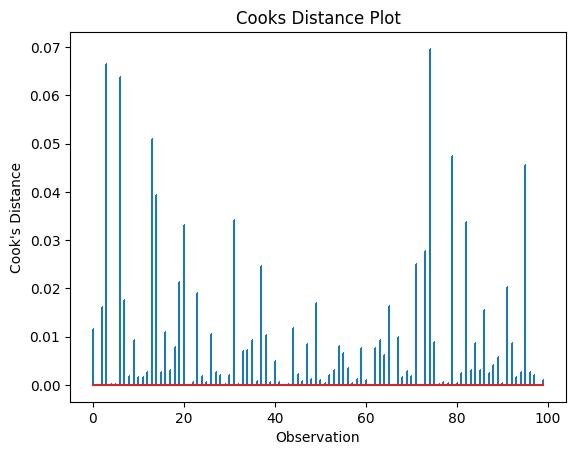

In [40]:
# plot the result
influence = model.get_influence()
cooks = influence.cooks_distance[0]

plt.stem(np.arange(len(df)), cooks, markerfmt=",")
plt.xlabel("Observation")
plt.ylabel("Cook's Distance")
plt.title("Cooks Distance Plot")
plt.show()

In [41]:
# multicollinearity - VIF score
df["X2"] = df["X"]*0.8 + np.random.normal(0,3,100)
df.head()

,X,y,pred,residuals,cook_distance,X2
0,0.00000,2.490142,0.481561,2.008581,0.011511,-4.246112
1,0.10101,0.787227,0.687761,0.099466,0.000027,-1.181128
2,0.20202,3.347106,0.893961,2.453145,0.016078,-0.866527
3,0.30303,6.175150,1.100161,5.074989,0.066560,-2.164408
4,0.40404,1.105621,1.306361,-0.200741,0.000101,-0.160625


In [42]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(df[["X", "X2"]])
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

  Variable       VIF
0    const  3.940760
1        X  1.681669
2       X2  1.681669


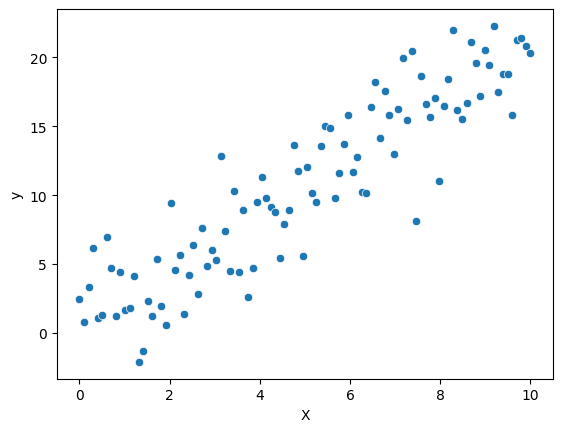

In [43]:
# detect non-linearity
sns.scatterplot(x=df["X"], y=df["y"])
plt.show()

In [44]:
# add polynomical features and comparison
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

poly = PolynomialFeatures(degree=2)
Xp = poly.fit_transform(df[["X"]])

model_poly = LinearRegression().fit(Xp, df['y'])
pred_poly = model_poly.predict(Xp)

mse_poly = mean_squared_error(df['y'], pred_poly)
print("MSE with polynomial features:", mse_poly)

MSE with polynomial features: 7.306188187924487


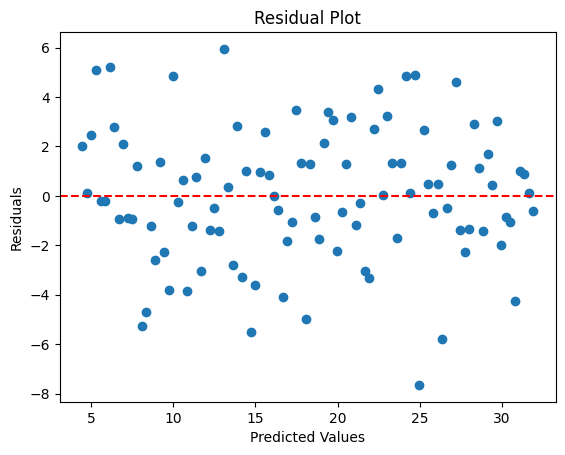

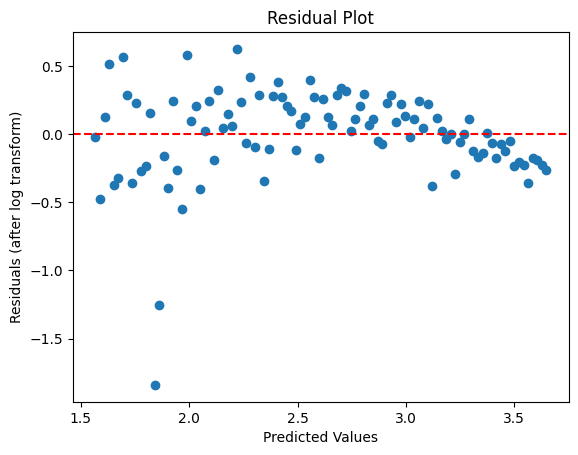

In [45]:
# log and swrt transform exmple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = np.linspace(1,10,100)
y = 3*X + 2 + np.random.normal(0,3,100)

df = pd.DataFrame({"X": X, "y": y})

# develop of the regression model
model = LinearRegression()
model.fit(df[["X"]], df["y"])
df["pred"] = model.predict(df[["X"]])
df["residuals"] = df["y"] - df["pred"]

# plot the scatter chart
plt.scatter(df["pred"], df["residuals"])
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# shift y and log it
y_shifted = df["y"] - df["y"].min() + 1
df["y_shifted"] = np.log(y_shifted)

model_log = LinearRegression().fit(df[["X"]], df['y_shifted'])
df["pred_log"] = model_log.predict(df[["X"]])
df["residuals_log"] = df["y_shifted"] - df["pred_log"]

# plot the scatter chart
plt.scatter(df["pred_log"], df["residuals_log"])
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (after log transform)")
plt.title("Residual Plot")
plt.show()

In [46]:
# 10. Regularization

from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=10).fit(df[['X']], df["y"])
lasso = Lasso(alpha=.01).fit(df[['X']], df["y"])

df["pred_ridge"] = ridge.predict(df[["X"]])
df["pred_lasso"] = lasso.predict(df[["X"]])

# print the coefs
print("Ridge coefs", ridge.coef_)
print("Lasso coefs", lasso.coef_)

Ridge coefs [3.00237866]
Lasso coefs [3.04452541]


## Time series models

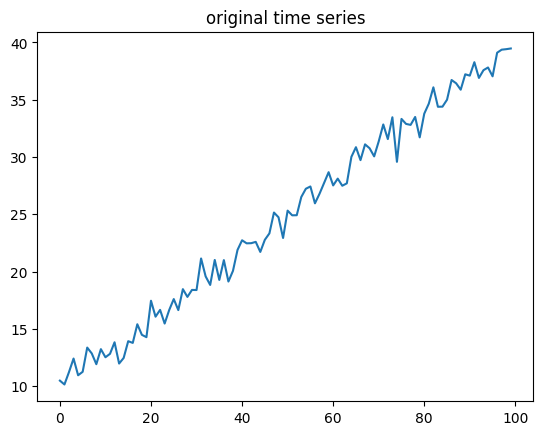

In [47]:
# 1. ARIMA models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# create random synthetic time series data
np.random.seed(42)
n = 100

time = np.arange(n)
trend = 0.3 * time
noise = np.random.normal(0, 1, n)
series = trend + noise + 10

df = pd.Series(series)
plt.plot(df)
plt.title("original time series")
plt.show()

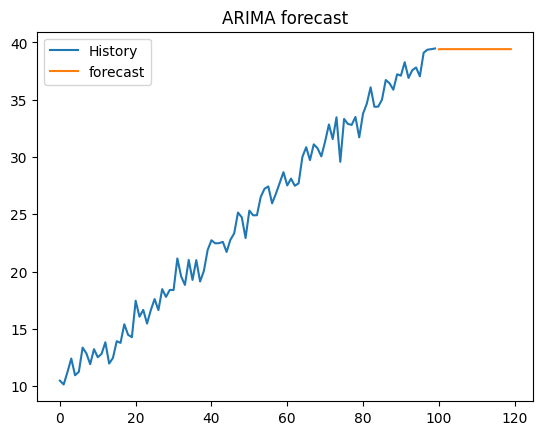

In [48]:
# fit the arima model on the df
model = ARIMA(df, order=(1, 1, 1))
model_fit = model.fit()

# forecast for next 20 steps
forecast_steps = 20
forecast = model_fit.forecast(steps=forecast_steps)

# create the index for the forecast range
forecast_index = np.arange(len(df), len(df) + forecast_steps)

plt.plot(df, label="History")
plt.plot(forecast_index, forecast, label="forecast")
plt.title("ARIMA forecast")
plt.legend()
plt.show()

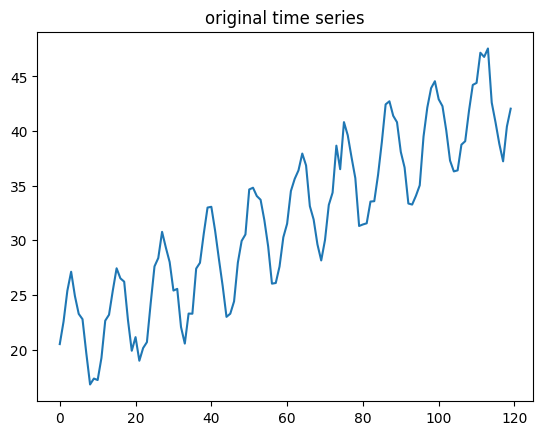

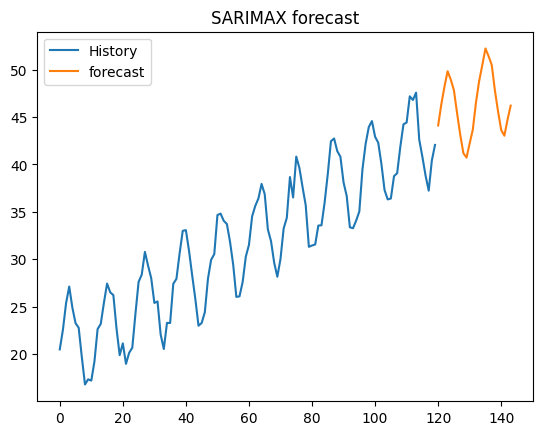

In [52]:
# SARIMAX
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

np.random.seed(42)
n = 120

time = np.arange(n)

# time series components
trend = 0.2 * time
seasonality = 5 * np.sin(2*np.pi*time /12)
noise = np.random.normal(0,1,n)

# seasonal time series
series = 20 + trend + seasonality + noise

df = pd.Series(series)
plt.plot(df)
plt.title("original time series")
plt.show()

# develop the SARIMAX model
model = SARIMAX(df,
                order=(1, 1, 1),
                seasonal_order=(1,1,1,12))
model_fit = model.fit()

# forecast for 24 months
forecast_steps = 24
forecast = model_fit.forecast(steps=forecast_steps)
forecast_index = np.arange(len(df), len(df) + forecast_steps)

# plot the historical + forecast
plt.plot(df, label="History")
plt.plot(forecast_index, forecast, label="forecast")
plt.title("SARIMAX forecast")
plt.legend()
plt.show()

## Classification models

In [51]:
# 1. logistics regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [65]:
np.random.seed(42)

n = 500
x1 = np.random.normal(0,1,n)
x2 = np.random.normal(0,1,n)

y = (x1*2 + x2*2 >1).astype(int)

df = pd.DataFrame({"x1": x1, "x2": x2, "y": y})
df.head()

,x1,x2,y
0,0.496714,0.926178,1
1,-0.138264,1.909417,1
2,0.647689,-1.398568,0
3,1.523030,0.562969,1
4,-0.234153,-0.650643,0


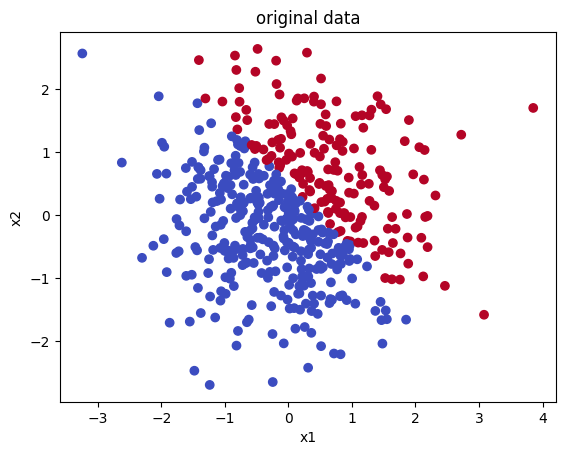

In [66]:
# visuallize the data
plt.scatter(df["x1"], df["x2"], c=df["y"], cmap="coolwarm")
plt.title("original data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()